# Pipeline de Clasificación con scikit-learn

<div style="background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); color:#f8fafc; padding:28px 32px; border-radius:18px; margin-bottom:16px; border-left:6px solid #219ebc; box-shadow:0 20px 45px rgba(0,0,0,0.35);">
  <h1 style="margin:0 0 6px 0; font-size:2.1rem; letter-spacing:-0.02em;">Notebook 2: Pipeline de Clasificación con scikit-learn</h1>
  <p style="margin:0; font-size:1.05rem; line-height:1.65; color:#94a3b8;">
    Este notebook implementa el pipeline completo de clasificación con <b style="color:#f8fafc;">MLPClassifier</b> sobre una muestra de <b style="color:#f8fafc;">1 millón de registros</b> del dataset Avazu.
  </p>
</div>

<p style="margin-bottom:18px;">
  <span style="background-color:#0f172a; color:#8ecae6; border:1px solid #219ebc; padding:4px 12px; border-radius:999px; font-weight:600; font-size:0.88rem;">Model: MLPClassifier</span>
  <span style="background-color:#0f172a; color:#ffb703; border:1px solid #fb8500; padding:4px 12px; border-radius:999px; font-weight:600; font-size:0.88rem; margin-left:6px;">1M registros</span>
  <span style="background-color:#0f172a; color:#c4b5fd; border:1px solid #7c3aed; padding:4px 12px; border-radius:999px; font-weight:600; font-size:0.88rem; margin-left:6px;">Framework: scikit-learn</span>
</p>

<div style="display:flex; flex-wrap:wrap; gap:10px; margin-bottom:14px;">
  <div style="flex:1; min-width:280px; background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); border-left:4px solid #219ebc; padding:14px 18px; border-radius:12px; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
    <p style="margin:0 0 6px 0; font-weight:700; color:#8ecae6; font-size:0.95rem;">Contenido</p>
    <p style="margin:0; color:#cbd5e1; font-size:0.88rem; line-height:1.65;">
      1. <b style="color:#e2e8f0;">Carga y muestreo</b> del dataset (1,000,000 registros estratificados)<br>
      2. <b style="color:#e2e8f0;">Feature Engineering</b> — codificación (Target Encoding + OneHot) y escalado<br>
      3. <b style="color:#e2e8f0;">Modelado</b> — MLPClassifier con GridSearchCV<br>
      4. <b style="color:#e2e8f0;">Evaluación</b> — métricas completas, curva ROC, matriz de confusión<br>
      5. <b style="color:#e2e8f0;">Análisis de resultados</b> y mejores hiperparámetros<br>
      6. <b style="color:#e2e8f0;">Guardado del modelo</b> en <code style="background:#1e293b; color:#67e8f9; padding:2px 6px; border-radius:4px;">models/</code>
    </p>
  </div>
  <div style="flex:1; min-width:280px; background: linear-gradient(135deg, #1a0f2e 0%, #0f172a 100%); border-left:4px solid #c4b5fd; padding:14px 18px; border-radius:12px; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
    <p style="margin:0 0 6px 0; font-weight:700; color:#c4b5fd; font-size:0.95rem;">Requisitos</p>
    <p style="margin:0; color:#cbd5e1; font-size:0.88rem; line-height:1.65;">
      Dataset en <code style="background:#1e293b; color:#67e8f9; padding:2px 6px; border-radius:4px;">data/raw/train.gz</code><br>
      Librerías: scikit-learn, pandas, matplotlib, seaborn<br>
      Notebook 1 ejecutado previamente (para contexto, no dependencia técnica)
    </p>
  </div>
</div>

## 0.1 Configuración del Entorno

<div style="background: linear-gradient(135deg, #1a0f2e 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #c4b5fd; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#c4b5fd;">0.1</span> &nbsp;Configuración del Entorno
  </h2>
</div>

> **Importamos las librerías necesarias y aplicamos el estilo visual oscuro profesional consistente con todo el proyecto.**

In [1]:
import sys
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("No se encontró la raíz del proyecto con el directorio src.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from ctr_mlp.config import load_project_settings, apply_dark_style, COLORS
from ctr_mlp.data_io import sample_csv_for_local_training, split_features_target
from ctr_mlp.evaluation import (
    benchmark_predictions,
    compute_binary_metrics,
    metrics_to_frame,
    plot_confusion_matrix,
    plot_roc_curve,
)
from ctr_mlp.feature_engineering import add_time_features_pandas
from ctr_mlp.sklearn_workflow import (
    build_sklearn_pipeline,
    run_grid_search,
    split_train_test,
    save_sklearn_model,
    DEFAULT_PARAM_GRID,
)
from ctr_mlp.utils import format_seconds

# Aplicar estilo oscuro profesional
apply_dark_style()

settings = load_project_settings()
paths = settings["paths"]
general = settings["general"]
feature_cfg = settings["features"]

TRAIN_PATH = paths["train_csv"]
SAMPLE_PATH = paths["sampled_train_parquet"]
FIGURES_DIR = paths["figures_dir"]
MODELS_DIR = paths["models_dir"]
TARGET_COL = general["target_col"]

print(f"Tamaño de muestra objetivo: {general['sample_size']:,}")
print(f"Random state: {general['random_state']}")

Tamaño de muestra objetivo: 1,000,000
Random state: 42


## 1.1 Muestreo de 1,000,000 de Registros

<div style="background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #219ebc; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#8ecae6;">1.1</span> &nbsp;Muestreo de 1,000,000 de Registros
  </h2>
</div>

> **Creamos una muestra estratificada de 1M de registros usando `df.sample(n=1000000, random_state=42)`. La muestra se cachea en formato Parquet para reutilización eficiente. Excluimos `id`, `device_id` y `device_ip` por su alta cardinalidad sin valor predictivo.**

In [2]:
# Columnas necesarias para el pipeline sklearn (excluir id, device_id, device_ip)
raw_local_columns = sorted({
    TARGET_COL,
    general["hour_col"],
    *[col for col in feature_cfg["sklearn_categorical"] if col != "time_bucket"],
})
print(f"Columnas a muestrear: {raw_local_columns}")

# Generar o reutilizar muestra cacheada
regenerate_sample = True
if SAMPLE_PATH.exists():
    df_sample = pd.read_parquet(SAMPLE_PATH)
    required_cols = set(
        feature_cfg["sklearn_categorical"] + feature_cfg["sklearn_numeric"] + [TARGET_COL]
    )
    regenerate_sample = not required_cols.issubset(df_sample.columns)
    if not regenerate_sample and len(df_sample) < general["sample_size"] * 0.9:
        regenerate_sample = True

if regenerate_sample:
    print(f"Generando muestra de {general['sample_size']:,} registros...")
    t0 = time.time()
    df_sample = sample_csv_for_local_training(
        TRAIN_PATH,
        sample_size=general["sample_size"],
        chunksize=general["chunksize"],
        target_col=TARGET_COL,
        random_state=general["random_state"],
        usecols=raw_local_columns,
        compression="gzip",
    )
    df_sample = add_time_features_pandas(df_sample, hour_col=general["hour_col"])
    SAMPLE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_sample.to_parquet(SAMPLE_PATH, index=False)
    print(f"Muestra generada en {time.time() - t0:.1f}s y guardada en: {SAMPLE_PATH}")
else:
    print(f"Reutilizando muestra cacheada: {SAMPLE_PATH}")

print(f"\nShape de la muestra: {df_sample.shape}")
memory_mb = df_sample.memory_usage(deep=True).sum() / 1024**2
print(f"Memoria aproximada: {memory_mb:,.2f} MB")

Columnas a muestrear: ['C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'app_category', 'banner_pos', 'click', 'device_conn_type', 'device_type', 'hour', 'site_category']
Generando muestra de 1,000,000 registros...
Muestra generada en 220.5s y guardada en: C:\Users\juana\Deep_learning1-main\data\processed\avazu_train_sample.parquet

Shape de la muestra: (999994, 23)
Memoria aproximada: 114.49 MB


In [3]:
# Distribución del target en la muestra
sample_counts = df_sample[TARGET_COL].value_counts().sort_index()
sample_stats = pd.DataFrame({
    "count": sample_counts,
    "share": (sample_counts / sample_counts.sum()).round(4),
})
print("Distribución del target en la muestra:")
display(sample_stats)

Distribución del target en la muestra:


,count,share
click,,
0,830194,0.8302
1,169800,0.1698


## 2.1 Selección de Variables y Preparación del Dataset de Modelado

<div style="background: linear-gradient(135deg, #1c1408 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #ffb703; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#ffb703;">2.1</span> &nbsp;Selección de Variables y Preparación del Dataset de Modelado
  </h2>
</div>

> **Seleccionamos las variables relevantes y separamos features (X) del target (y). Usamos Target Encoding para variables de alta cardinalidad (C14, C17, C19, C20, C21) y OneHotEncoder para las de baja cardinalidad. Las variables numéricas derivadas se escalan con StandardScaler.**

In [4]:
selected_cols = feature_cfg["sklearn_categorical"] + feature_cfg["sklearn_numeric"] + [TARGET_COL]
model_df = df_sample[selected_cols].dropna().copy()

X, y = split_features_target(model_df, target_col=TARGET_COL)
X_train, X_test, y_train, y_test = split_train_test(
    X, y, test_size=0.2, random_state=general["random_state"]
)

print("Variables categóricas de BAJA cardinalidad (OneHot Encoding):")
print(f"  {feature_cfg['sklearn_low_cardinality']}")
print(f"\nVariables categóricas de ALTA cardinalidad (Target Encoding):")
print(f"  {feature_cfg['sklearn_high_cardinality']}")
print(f"\nVariables numéricas (StandardScaler):")
print(f"  {feature_cfg['sklearn_numeric']}")
print(f"\nTrain shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Balance en train: {y_train.mean():.4f} | Balance en test: {y_test.mean():.4f}")

Variables categóricas de BAJA cardinalidad (OneHot Encoding):
  ['C1', 'banner_pos', 'site_category', 'app_category', 'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'time_bucket']

Variables categóricas de ALTA cardinalidad (Target Encoding):
  ['C14', 'C17', 'C19', 'C20', 'C21']

Variables numéricas (StandardScaler):
  ['event_day', 'event_hour', 'day_of_week', 'is_weekend', 'is_business_hour']

Train shape: (799995, 20) | Test shape: (199999, 20)
Balance en train: 0.1698 | Balance en test: 0.1698


## 3.1 Construcción del Pipeline y GridSearchCV

<div style="background: linear-gradient(135deg, #0f1a0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #90be6d; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#90be6d;">3.1</span> &nbsp;Construcción del Pipeline y GridSearchCV
  </h2>
</div>

> **Construimos un pipeline que integra el preprocesamiento (Target Encoding + OneHot + StandardScaler) con el MLPClassifier. Ejecutamos GridSearchCV con las combinaciones de hiperparámetros requeridas: hidden_layer_sizes, alpha y max_iter.**

In [5]:
# Construir pipeline con Target Encoding para alta cardinalidad
pipeline = build_sklearn_pipeline(
    categorical_columns=feature_cfg["sklearn_categorical"],
    numeric_columns=feature_cfg["sklearn_numeric"],
    high_cardinality_columns=feature_cfg["sklearn_high_cardinality"],
    random_state=general["random_state"],
)

# Grilla de hiperparámetros completa (según requerimientos)
param_grid = {
    "classifier__hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "classifier__alpha": [0.0001, 0.001, 0.01],
    "classifier__max_iter": [50, 100],
}

print("Hiperparámetros a explorar:")
for key, values in param_grid.items():
    print(f"  {key}: {values}")
total_combos = 1
for v in param_grid.values():
    total_combos *= len(v)
print(f"\nTotal de combinaciones: {total_combos} × 3 folds = {total_combos * 3} ajustes")

Hiperparámetros a explorar:
  classifier__hidden_layer_sizes: [(50,), (100,), (100, 50)]
  classifier__alpha: [0.0001, 0.001, 0.01]
  classifier__max_iter: [50, 100]

Total de combinaciones: 18 × 3 folds = 54 ajustes


In [6]:
# Ejecutar GridSearchCV (mide tiempo automáticamente)
print("Iniciando GridSearchCV...")
t_start = time.time()
search, training_seconds = run_grid_search(
    pipeline,
    X_train,
    y_train,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1,
)
t_total = time.time() - t_start
print(f"\nGridSearchCV completado en: {format_seconds(t_total)}")
print(f"Tiempo total de entrenamiento: {format_seconds(training_seconds)}")

Iniciando GridSearchCV...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

GridSearchCV completado en: 12m 8.7s
Tiempo total de entrenamiento: 12m 8.6s


## 3.2 Mejores Hiperparámetros Encontrados

<div style="background: linear-gradient(135deg, #0f1a0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #90be6d; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#90be6d;">3.2</span> &nbsp;Mejores Hiperparámetros Encontrados
  </h2>
</div>

> **Revisamos los resultados de la validación cruzada para identificar la mejor combinación de hiperparámetros y entender el trade-off entre complejidad del modelo y rendimiento.**

In [7]:
# Mejores hiperparámetros
print("Mejores hiperparámetros encontrados:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMejor ROC AUC (CV): {search.best_score_:.4f}")

# Tabla completa de resultados CV
cv_results = (
    pd.DataFrame(search.cv_results_)
    .sort_values("rank_test_score")
    [["params", "mean_test_score", "std_test_score", "rank_test_score"]]
    .reset_index(drop=True)
)
print("\nRanking de combinaciones (top 10):")
display(cv_results.head(10))

Mejores hiperparámetros encontrados:
  classifier__alpha: 0.0001
  classifier__hidden_layer_sizes: (100, 50)
  classifier__max_iter: 100

Mejor ROC AUC (CV): 0.7052

Ranking de combinaciones (top 10):


,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__alpha': 0.0001, 'classifier__hid...",0.705248,0.003038,1
1,"{'classifier__alpha': 0.001, 'classifier__hidd...",0.704864,0.002372,2
2,"{'classifier__alpha': 0.0001, 'classifier__hid...",0.704565,0.002422,3
3,"{'classifier__alpha': 0.001, 'classifier__hidd...",0.703913,0.001885,4
4,"{'classifier__alpha': 0.01, 'classifier__hidde...",0.703633,0.002082,5
5,"{'classifier__alpha': 0.0001, 'classifier__hid...",0.703363,0.001688,6
6,"{'classifier__alpha': 0.0001, 'classifier__hid...",0.703265,0.002515,7
7,"{'classifier__alpha': 0.001, 'classifier__hidd...",0.703256,0.001637,8
8,"{'classifier__alpha': 0.001, 'classifier__hidd...",0.703145,0.002377,9
9,"{'classifier__alpha': 0.001, 'classifier__hidd...",0.703081,0.000304,10


## 4.1 Evaluación del Mejor Modelo en el Conjunto de Prueba

<div style="background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #f28482; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#f28482;">4.1</span> &nbsp;Evaluación del Mejor Modelo en el Conjunto de Prueba
  </h2>
</div>

> **Evaluamos el mejor modelo encontrado por GridSearchCV sobre el conjunto de prueba (20% de la muestra). Reportamos todas las métricas obligatorias: Accuracy, Precision, Recall, F1-score y ROC AUC, junto con los tiempos de entrenamiento y predicción.**

In [8]:
# Predicción y medición de tiempo
y_pred, y_score, prediction_seconds = benchmark_predictions(search.best_estimator_, X_test)

# Calcular todas las métricas
metrics = compute_binary_metrics(y_test, y_pred, y_score=y_score)
metrics["training_seconds"] = training_seconds
metrics["prediction_seconds"] = prediction_seconds

# Mostrar métricas como tabla
print("═" * 50)
print("MÉTRICAS DEL MEJOR MODELO (scikit-learn)")
print("═" * 50)
print(f"  Accuracy:    {metrics['accuracy']:.4f}")
print(f"  Precision:   {metrics['precision']:.4f}")
print(f"  Recall:      {metrics['recall']:.4f}")
print(f"  F1-score:    {metrics['f1']:.4f}")
print(f"  ROC AUC:     {metrics['roc_auc']:.4f}")
print(f"═" * 50)
print(f"  Tiempo entrenamiento: {format_seconds(training_seconds)}")
print(f"  Tiempo predicción:    {format_seconds(prediction_seconds)}")
print(f"═" * 50)

display(metrics_to_frame(metrics))

══════════════════════════════════════════════════
MÉTRICAS DEL MEJOR MODELO (scikit-learn)
══════════════════════════════════════════════════
  Accuracy:    0.8325
  Precision:   0.5883
  Recall:      0.0460
  F1-score:    0.0854
  ROC AUC:     0.7053
══════════════════════════════════════════════════
  Tiempo entrenamiento: 12m 8.6s
  Tiempo predicción:    0.94s
══════════════════════════════════════════════════


,value
accuracy,0.832544
precision,0.588257
recall,0.046025
f1,0.085370
roc_auc,0.705311
true_negative,164945.000000
false_positive,1094.000000
false_negative,32397.000000
true_positive,1563.000000
training_seconds,728.632217


## 4.2 Matriz de Confusión

<div style="background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #f28482; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#f28482;">4.2</span> &nbsp;Matriz de Confusión
  </h2>
</div>

> **La matriz de confusión muestra la distribución de aciertos y errores del clasificador. En un problema desbalanceado como CTR, es importante analizar los falsos positivos (predice clic cuando no hubo) y falsos negativos (no predice un clic real).**

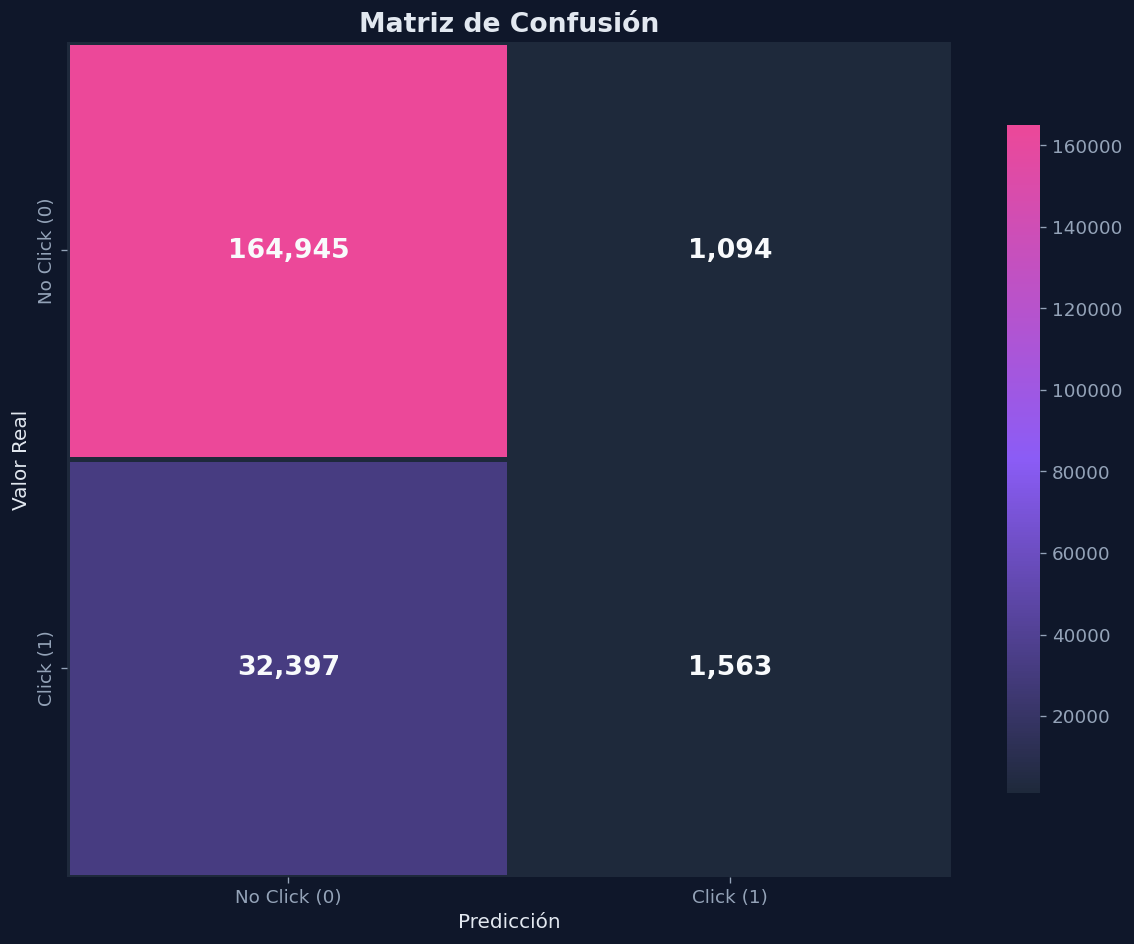

In [9]:
fig_cm = plot_confusion_matrix(
    y_test, y_pred,
    save_path=FIGURES_DIR / "02_confusion_matrix.png"
)
plt.show()

## 4.3 Curva ROC

<div style="background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #f28482; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#f28482;">4.3</span> &nbsp;Curva ROC
  </h2>
</div>

> **La curva ROC visualiza el trade-off entre la tasa de verdaderos positivos (sensibilidad) y la tasa de falsos positivos a diferentes umbrales de clasificación. El área bajo la curva (AUC) resume la capacidad discriminativa del modelo.**

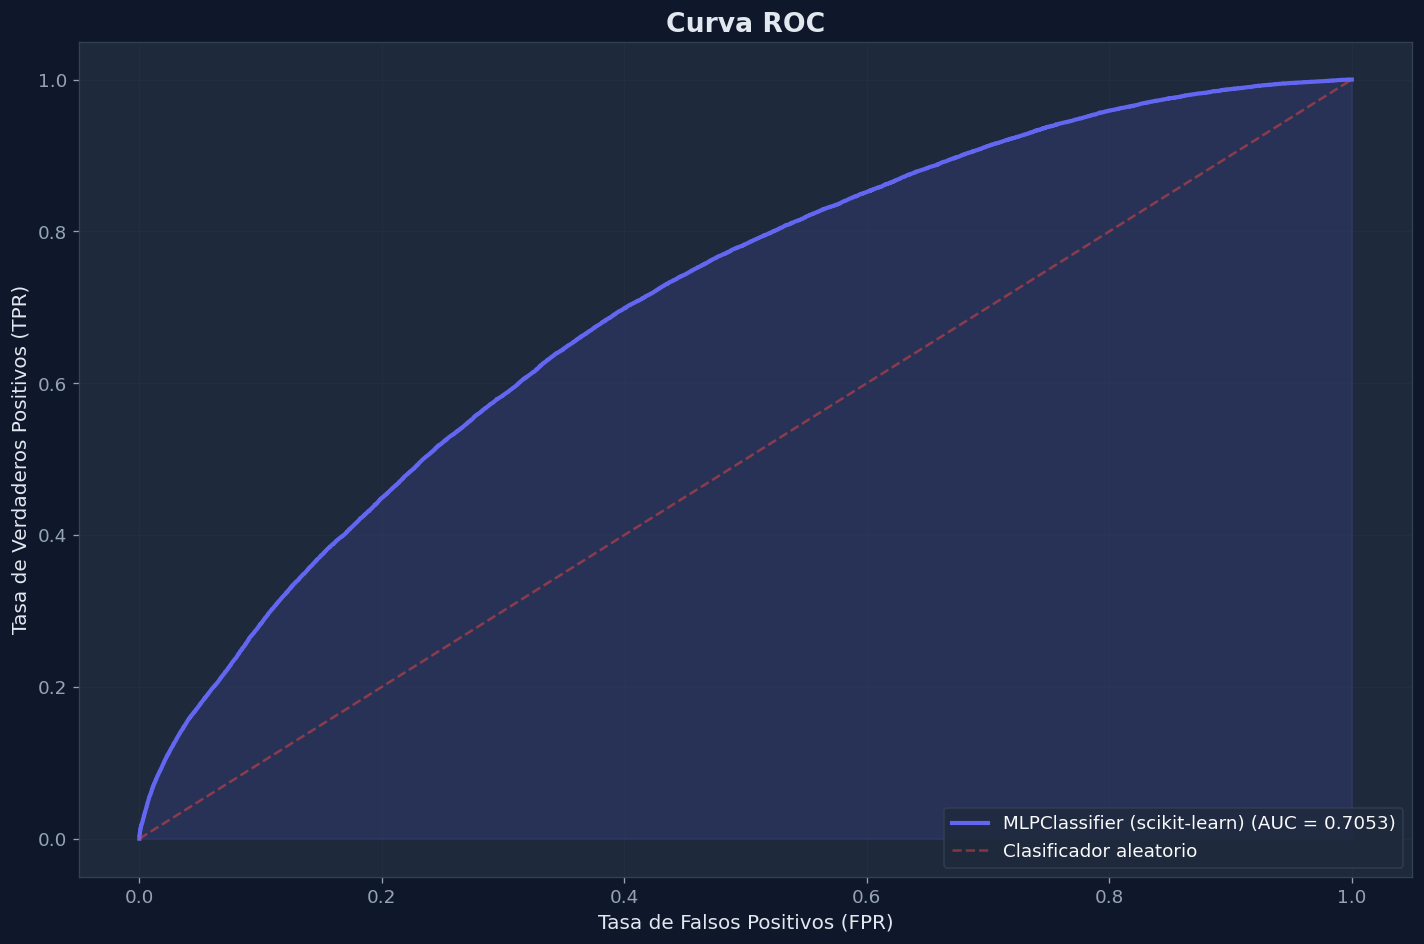

In [10]:
fig_roc = plot_roc_curve(
    y_test, y_score,
    model_name="MLPClassifier (scikit-learn)",
    save_path=FIGURES_DIR / "02_roc_curve_sklearn.png"
)
plt.show()

## 5.1 Guardado del Mejor Modelo

<div style="background: linear-gradient(135deg, #1c1408 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #fb8500; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#fb8500;">5.1</span> &nbsp;Guardado del Mejor Modelo
  </h2>
</div>

> **Guardamos el mejor modelo encontrado por GridSearchCV en el directorio `models/` para su reutilización en el notebook de explicabilidad (LIME) y en la comparación final.**

In [11]:
model_path = save_sklearn_model(
    search.best_estimator_,
    save_path=MODELS_DIR,
    filename="sklearn_best_mlp.joblib"
)
print(f"\nMejores hiperparámetros del modelo guardado:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")

Modelo guardado en: C:\Users\juana\Deep_learning1-main\models\sklearn_best_mlp.joblib

Mejores hiperparámetros del modelo guardado:
  classifier__alpha: 0.0001
  classifier__hidden_layer_sizes: (100, 50)
  classifier__max_iter: 100


## 5.2 Guardado de Métricas y Datos para Comparación

<div style="background: linear-gradient(135deg, #1c1408 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #fb8500; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#fb8500;">5.2</span> &nbsp;Guardado de Métricas y Datos para Comparación
  </h2>
</div>

> **Guardamos las métricas, predicciones y datos de test en formato parquet para poder cargarlos en el Notebook 4 y realizar la comparación con PySpark sin necesidad de re-entrenar.**

In [12]:
# Guardar métricas como CSV
metrics_df = pd.DataFrame([metrics])
metrics_path = Path(MODELS_DIR) / "sklearn_metrics.csv"
metrics_path.parent.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(metrics_path, index=False)
print(f"Métricas guardadas en: {metrics_path}")

# Guardar predicciones para comparación ROC en Notebook 4
predictions_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
    "y_score": y_score,
})
pred_path = Path(MODELS_DIR) / "sklearn_predictions.parquet"
predictions_df.to_parquet(pred_path, index=False)
print(f"Predicciones guardadas en: {pred_path}")

Métricas guardadas en: C:\Users\juana\Deep_learning1-main\models\sklearn_metrics.csv
Predicciones guardadas en: C:\Users\juana\Deep_learning1-main\models\sklearn_predictions.parquet


## 6. Conclusiones del Pipeline scikit-learn

<div style="background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #219ebc; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#8ecae6;">6.</span> &nbsp;Conclusiones del Pipeline scikit-learn
  </h2>
</div>

> **Resumen de los resultados y observaciones del pipeline local.**

<div style="background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); color:#f8fafc; padding:16px 22px; border-radius:12px; margin-bottom:6px; border-left:4px solid #219ebc; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
  <h3 style="margin:0; font-size:1.15rem; color:#e2e8f0;">
    Observaciones clave:
  </h3>
</div>

1. **Target Encoding**: Las variables de alta cardinalidad (C14, C17, C19, C20, C21) se codificaron con Target Encoding, lo que reduce significativamente la dimensionalidad respecto a OneHot Encoding puro.

2. **Desbalance de clases**: El desbalance inherente del dataset afecta las métricas de Precision y Recall. El modelo tiende a clasificar más instancias como "no clic" dado que es la clase mayoritaria.

3. **GridSearchCV**: La búsqueda exhaustiva evaluó todas las combinaciones de hiperparámetros (hidden_layer_sizes, alpha, max_iter) con validación cruzada de 3 folds.

4. **Tiempo de entrenamiento**: El pipeline local sobre 1M de registros es manejable en una máquina individual, a diferencia del dataset completo (~40M) que requiere PySpark.

5. **Modelo guardado**: El mejor modelo se guardó en `models/sklearn_best_mlp.joblib` para reutilización en LIME (Notebook 4).